In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.9.1 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.0 pandas==1.5.3 scikit-learn==1.2.1 statsmodels==0.13.5 python-igraph==0.10.4 pynndescent==0.5.8


In [3]:
adata=sc.read_h5ad('Merged_lowGeneMin.unknown-rna.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 996162 × 44876
    obs: 'n_genes', 'n_counts', 'Channel', 'percent_mito', 'scale', 'louvain_labels'
    var: 'featureid', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    uns: 'Channels', 'PCs', 'W_pca', 'df_qcplot', 'genome', 'louvain_resolution', 'modality', 'norm_count', 'pca', 'pca_features', 'pca_knn_distances', 'pca_knn_indices', 'scale.data', 'scale.data.rownames', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std'
    obsm: 'X_pca', 'X_umap'
    varm: 'de_res'

In [5]:
adata.obs.Channel.value_counts()

TWCM-11-78      80190
TWCM-H3         76440
TWCM-11-264     66641
TWCM-H4         52120
TWCM-H5         45987
TWCM-13-168     44679
TWCM-11-42      34212
TWCM-13-192     33397
TWCM-13-80      32033
TWCM-H1         29036
TWCM-LVAD3      26593
TWCM-13-1       26104
TWCM-H8-lib1    25496
TWCM-13-181     24784
TWCM-13-104     21951
TWCM-13-152     21371
TWCM-13-96      21276
TWCM-11-74      20143
TWCM-13-208     19916
TWCM-11-256     19505
H_ZC-11-292     19393
TWCM-14-173     19263
TWCM-13-235     18918
TWCM-11-104     18478
TWCM-13-36      17150
TWCM-11-93      16647
TWCM-13-198     16148
H_ZC-LVAD-1     16037
TWCM-10-68      15697
TWCM-11-103     15031
TWCM-11-192     14680
TWCM-13-132     13495
TWCM-13-101     11992
TWCM-LVAD2      10404
TWCM-11-41      10366
TWCM-11-3        9286
TWCM-13-285      8398
TWCM-13-102      7779
TWCM-13-47       5940
TWCM-13-17       5791
TWCM-10-5        3395
Name: Channel, dtype: int64

In [6]:
adata.obs

,n_genes,n_counts,Channel,percent_mito,scale,louvain_labels
barcodekey,,,,,,
H_ZC-11-292-AAACCTGAGAAGCCCA,90,113,H_ZC-11-292,5.309735,884.955752,12
H_ZC-11-292-AAACCTGAGAAGGACA,361,492,H_ZC-11-292,1.219512,203.252033,7
H_ZC-11-292-AAACCTGAGAAGGCCT,584,875,H_ZC-11-292,0.571429,114.810563,8
H_ZC-11-292-AAACCTGAGCACAGGT,1394,2239,H_ZC-11-292,0.491291,44.782803,9
H_ZC-11-292-AAACCTGAGCACCGCT,557,790,H_ZC-11-292,0.506329,126.742712,8
...,...,...,...,...,...,...
TWCM-LVAD3-TTTGTCATCGCTAGCG,85,117,TWCM-LVAD3,5.128205,854.700855,3
TWCM-LVAD3-TTTGTCATCGGACAAG,897,1260,TWCM-LVAD3,1.666667,79.428118,8
TWCM-LVAD3-TTTGTCATCTCGCTTG,429,549,TWCM-LVAD3,3.460838,182.815356,7


In [7]:
adata.obs['original_barcodes']=adata.obs.index.copy()

In [8]:
adata.obs.index=adata.obs.index.str.replace('TWCM-H8-lib1-', 'HDCM8_')

In [9]:
adata.obs.index=adata.obs.index.str.replace('TWCM-H1-', 'HDCM1_')

In [10]:
adata.obs.index=adata.obs.index.str.replace('TWCM-H3-', 'HDCM3_')

In [11]:
adata.obs.index=adata.obs.index.str.replace('TWCM-H4-', 'HDCM4_')

In [12]:
adata.obs.index=adata.obs.index.str.replace('TWCM-H5-', 'HDCM5_')

In [13]:
adata.obs[adata.obs.Channel.isin(['TWCM-H1'])]

,n_genes,n_counts,Channel,percent_mito,scale,louvain_labels,original_barcodes
barcodekey,,,,,,,
HDCM1_AAACCTGAGACGCACA,100,122,TWCM-H1,13.934426,826.446281,2,TWCM-H1-AAACCTGAGACGCACA
HDCM1_AAACCTGAGAGACTTA,62,66,TWCM-H1,6.060606,1515.151515,2,TWCM-H1-AAACCTGAGAGACTTA
HDCM1_AAACCTGAGATGTCGG,44,116,TWCM-H1,72.413793,862.068966,17,TWCM-H1-AAACCTGAGATGTCGG
HDCM1_AAACCTGAGCACGCCT,35,71,TWCM-H1,67.605634,1428.571429,17,TWCM-H1-AAACCTGAGCACGCCT
HDCM1_AAACCTGAGCCACGTC,49,58,TWCM-H1,24.137931,1724.137931,2,TWCM-H1-AAACCTGAGCCACGTC
...,...,...,...,...,...,...,...
HDCM1_TTTGTCATCGTTACAG,62,69,TWCM-H1,7.246377,1449.275362,2,TWCM-H1-TTTGTCATCGTTACAG
HDCM1_TTTGTCATCTAACCGA,54,58,TWCM-H1,3.448276,1724.137931,2,TWCM-H1-TTTGTCATCTAACCGA
HDCM1_TTTGTCATCTCTAAGG,1095,2045,TWCM-H1,15.501222,48.923679,15,TWCM-H1-TTTGTCATCTCTAAGG


In [14]:
adata_cells=adata[adata.obs.Channel.isin(['TWCM-H1', 'TWCM-H3', 'TWCM-H4','TWCM-H5', 'TWCM-H8-lib1'])]

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/anndata/compat/__init__.py:263: FutureWarning: During AnnData slicing, found matrix at .uns['W_pca'] that happens to be dimensioned at n_obs×n_obs (996162×996162).

These matrices should now be stored in the .obsp attribute.
This slicing behavior will be removed in anndata 0.8.
  warn(


In [15]:
adata_cells

View of AnnData object with n_obs × n_vars = 229079 × 44876
    obs: 'n_genes', 'n_counts', 'Channel', 'percent_mito', 'scale', 'louvain_labels', 'original_barcodes'
    var: 'featureid', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    uns: 'Channels', 'PCs', 'W_pca', 'df_qcplot', 'genome', 'louvain_resolution', 'modality', 'norm_count', 'pca', 'pca_features', 'pca_knn_distances', 'pca_knn_indices', 'scale.data', 'scale.data.rownames', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std'
    obsm: 'X_pca', 'X_umap'
    varm: 'de_res'

In [16]:
adata_cells.obs.Channel.value_counts()

TWCM-H3         76440
TWCM-H4         52120
TWCM-H5         45987
TWCM-H1         29036
TWCM-H8-lib1    25496
Name: Channel, dtype: int64

In [17]:
#TWCM-H1 is DCM
#TWCM-H3 is DCM
#TWCM-H4 is DCM
#TWCM-H5 is Donor
#TWCM-H8 is DCM


In [18]:
genedf_raw = sc.get.obs_df(adata_cells,
        keys=[ "Channel", 'CDKN2A_p14', 'CDKN2A_p16', 'CDKN2B', 'CDKN2B-AS1'], use_raw=True)


In [19]:
genedf_raw

,Channel,CDKN2A_p14,CDKN2A_p16,CDKN2B,CDKN2B-AS1
barcodekey,,,,,
HDCM1_AAACCTGAGACGCACA,TWCM-H1,0.0,0.0,0.0,0.0
HDCM1_AAACCTGAGAGACTTA,TWCM-H1,0.0,0.0,0.0,0.0
HDCM1_AAACCTGAGATGTCGG,TWCM-H1,0.0,0.0,0.0,0.0
HDCM1_AAACCTGAGCACGCCT,TWCM-H1,0.0,0.0,0.0,0.0
HDCM1_AAACCTGAGCCACGTC,TWCM-H1,0.0,0.0,0.0,0.0
...,...,...,...,...,...
HDCM8_TTTGTCATCGCAAGCC,TWCM-H8-lib1,0.0,0.0,0.0,0.0
HDCM8_TTTGTCATCGCACTCT,TWCM-H8-lib1,0.0,0.0,0.0,0.0
HDCM8_TTTGTCATCGCGATCG,TWCM-H8-lib1,0.0,0.0,0.0,0.0


In [20]:
genedf_raw.CDKN2A_p14.value_counts()

0.0    228591
1.0       457
2.0        24
3.0         5
4.0         1
5.0         1
Name: CDKN2A_p14, dtype: int64

In [21]:
genedf_raw.CDKN2A_p16.value_counts()

0.0    228969
1.0        93
2.0        14
6.0         1
4.0         1
3.0         1
Name: CDKN2A_p16, dtype: int64

In [22]:
genedf_raw.CDKN2B.value_counts()

0.0    227244
1.0      1691
2.0       125
3.0        12
4.0         6
6.0         1
Name: CDKN2B, dtype: int64

In [23]:
genedf_raw['CDKN2B-AS1'].value_counts()

0.0    228874
1.0       200
2.0         5
Name: CDKN2B-AS1, dtype: int64

In [24]:
genedf_raw.to_csv('Merged_lowGeneMin.unknown-rna.9p21.rawCounts.txt', sep='\t')

In [25]:
genedf_proc = sc.get.obs_df(adata_cells,
        keys=["Channel", 'CDKN2A_p14', 'CDKN2A_p16', 'CDKN2B', 'CDKN2B-AS1'])


In [26]:
genedf_proc.CDKN2A_p14.value_counts()

0.000000    228591
3.555076         2
7.082948         2
3.478375         2
3.678706         2
             ...  
3.928400         1
4.312646         1
3.787802         1
5.325441         1
3.683232         1
Name: CDKN2A_p14, Length: 477, dtype: int64

In [27]:
genedf_proc.CDKN2A_p16.value_counts()

0.000000    228969
7.488133         3
3.573077         2
3.540333         1
2.891875         1
             ...  
2.995671         1
4.035223         1
3.189214         1
4.045649         1
3.030723         1
Name: CDKN2A_p16, Length: 108, dtype: int64

In [28]:
genedf_proc.CDKN2B.value_counts()

0.000000    227244
7.601402         6
7.562201         4
7.524481         3
4.182932         3
             ...  
2.943681         1
2.381245         1
2.976473         1
4.604290         1
3.556067         1
Name: CDKN2B, Length: 1671, dtype: int64

In [29]:
genedf_proc['CDKN2B-AS1'].value_counts()

0.000000    228874
5.989979         2
4.034132         2
6.006004         2
4.399996         1
             ...  
2.052754         1
7.581610         1
2.551795         1
4.429030         1
1.674009         1
Name: CDKN2B-AS1, Length: 203, dtype: int64

In [30]:
genedf_proc.to_csv('Merged_lowGeneMin.unknown-rna.9p21.procCounts.txt', sep='\t')

In [31]:
orig=sc.read_h5ad('GSE183852_DCM_Cells.h5ad')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/anndata/compat/__init__.py:232: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


In [32]:
orig

AnnData object with n_obs × n_vars = 49723 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'seurat_clusters', 'Age_Group_Tertile', 'Sex', 'Condition', 'Names'
    var: 'sct.detection_rate', 'sct.gmean', 'sct.variance', 'sct.residual_variance', 'sct.variable'
    uns: 'neighbors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances'

In [33]:
orig.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mito,nCount_SCT,nFeature_SCT,SCT_snn_res.0.2,SCT_snn_res.0.3,SCT_snn_res.0.4,SCT_snn_res.0.5,SCT_snn_res.0.6,SCT_snn_res.0.7,SCT_snn_res.0.8,SCT_snn_res.0.9,SCT_snn_res.1,seurat_clusters,Age_Group_Tertile,Sex,Condition,Names
HDCM1_AAACCTGCACTGTCGG,HDCM1,4998.0,2076,3.161265,4648.0,2076,0,0,0,0,0,0,15,16,16,16,Middle,Male,DCM,0
HDCM1_AAAGATGCACCGCTAG,HDCM1,6029.0,2474,3.566097,4928.0,2472,0,0,0,0,0,0,0,1,0,0,Middle,Male,DCM,0
HDCM1_AAAGATGCAGGAATGC,HDCM1,2486.0,1387,3.740949,3608.0,1422,0,0,0,5,0,0,7,10,0,0,Middle,Male,DCM,0
HDCM1_AAAGCAAGTCCGTGAC,HDCM1,4673.0,2383,1.776161,4554.0,2383,0,0,0,0,0,0,0,1,0,0,Middle,Male,DCM,0
HDCM1_AAAGTAGCATACGCCG,HDCM1,5034.0,2107,2.522845,4650.0,2107,0,0,0,0,0,0,0,1,0,0,Middle,Male,DCM,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HDCM8_TTCCCAGAGAGGTAGA,HDCM8,3258.0,1164,7.397176,3945.0,1163,8,12,14,18,19,20,21,22,24,24,Young,Female,DCM,9
HDCM8_TTTCCTCCAGATGGCA,HDCM8,5454.0,1747,4.767143,4724.0,1747,8,12,14,18,19,20,21,22,24,24,Young,Female,DCM,9
HDCM8_TTTGTCATCGCGATCG,HDCM8,5947.0,1866,5.683538,4831.0,1860,8,12,14,18,19,20,21,22,24,24,Young,Female,DCM,9
HDCM8_GACTAACTCAGGCAAG,HDCM8,3710.0,1742,3.638814,4019.0,1742,4,6,15,19,20,21,3,23,25,25,Young,Female,DCM,10


In [34]:
cells_metad=pd.read_table('GSE183852_DCM_Cells.Robj.meta_data.txt')
cells_metad

,orig.ident,nCount_RNA,nFeature_RNA,percent.mito,nCount_SCT,nFeature_SCT,SCT_snn_res.0.2,SCT_snn_res.0.3,SCT_snn_res.0.4,SCT_snn_res.0.5,...,SCT_snn_res.1,seurat_clusters,Age_Group_Tertile,Sex,Condition,Names,SASP1,senmayo1,p14_top2001,p16_top2001
HDCM1_AAACCTGCACTGTCGG,HDCM1,4998,2076,3.161265,4648,2076,0,0,0,0,...,16,16,Middle,Male,DCM,Fibroblasts,0.033315,0.041229,0.023476,0.417586
HDCM1_AAAGATGCACCGCTAG,HDCM1,6029,2474,3.566097,4928,2472,0,0,0,0,...,0,0,Middle,Male,DCM,Fibroblasts,0.043132,0.072012,-0.016547,0.346154
HDCM1_AAAGATGCAGGAATGC,HDCM1,2486,1387,3.740949,3608,1422,0,0,0,5,...,0,0,Middle,Male,DCM,Fibroblasts,0.132584,0.155112,0.012478,0.218857
HDCM1_AAAGCAAGTCCGTGAC,HDCM1,4673,2383,1.776161,4554,2383,0,0,0,0,...,0,0,Middle,Male,DCM,Fibroblasts,0.101987,0.143490,0.012679,0.330804
HDCM1_AAAGTAGCATACGCCG,HDCM1,5034,2107,2.522845,4650,2107,0,0,0,0,...,0,0,Middle,Male,DCM,Fibroblasts,0.060492,0.037958,0.012083,0.347184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HDCM8_TTCCCAGAGAGGTAGA,HDCM8,3258,1164,7.397176,3945,1163,8,12,14,18,...,24,24,Young,Female,DCM,B_Cells,-0.064918,-0.038910,0.042922,0.057058
HDCM8_TTTCCTCCAGATGGCA,HDCM8,5454,1747,4.767143,4724,1747,8,12,14,18,...,24,24,Young,Female,DCM,B_Cells,-0.104651,-0.059621,0.007058,0.029321
HDCM8_TTTGTCATCGCGATCG,HDCM8,5947,1866,5.683538,4831,1860,8,12,14,18,...,24,24,Young,Female,DCM,B_Cells,-0.146748,-0.071439,0.019504,0.049560
HDCM8_GACTAACTCAGGCAAG,HDCM8,3710,1742,3.638814,4019,1742,4,6,15,19,...,25,25,Young,Female,DCM,Lymphatic,0.115740,0.092872,0.021372,0.345139


In [35]:
orig.obs['Cell_types']=cells_metad['Names']

In [36]:
card_cells=orig[orig.obs['orig.ident'].isin(['HDCM1', 'HDCM3', 'HDCM4','HDCM5', 'HDCM8'])]

In [37]:
card_cells

View of AnnData object with n_obs × n_vars = 35376 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'seurat_clusters', 'Age_Group_Tertile', 'Sex', 'Condition', 'Names', 'Cell_types'
    var: 'sct.detection_rate', 'sct.gmean', 'sct.variance', 'sct.residual_variance', 'sct.variable'
    uns: 'neighbors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances'

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/contextlib.py:126: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  next(self.gen)
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/u

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


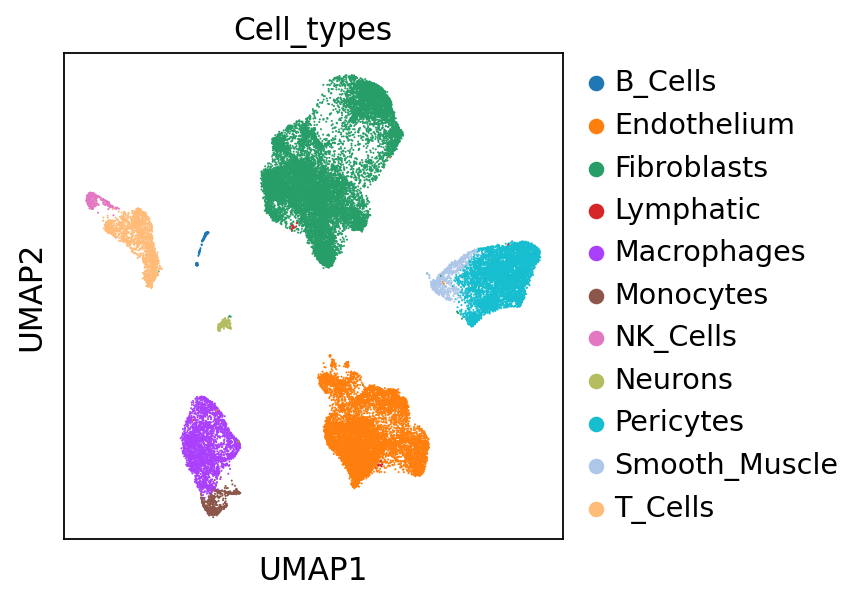

In [38]:
sc.pl.umap(card_cells, color=['Cell_types'], save="Koenig_5prime_Cell_types_forGH.pdf")

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


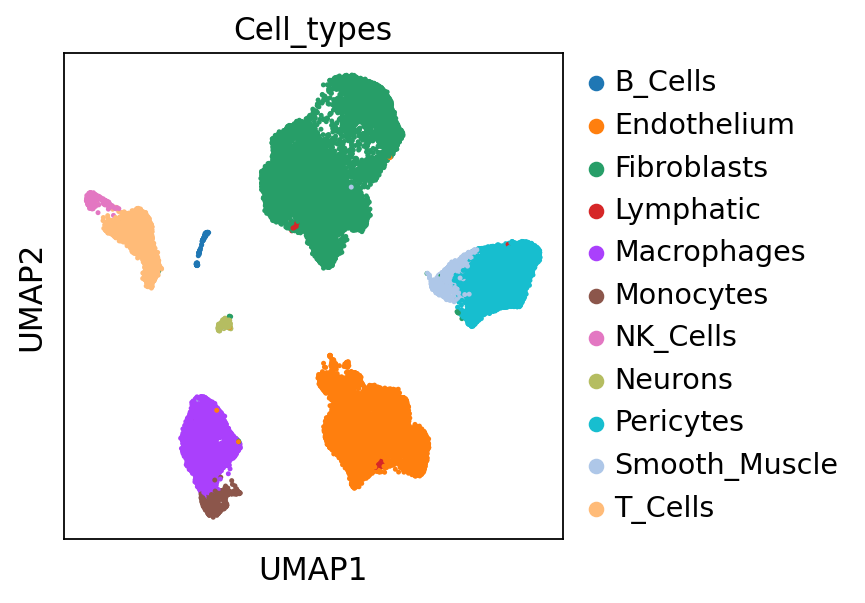

In [39]:
sc.pl.umap(card_cells, color=['Cell_types'],size=20, save="Koenig_5prime_Cell_types_biggerdots_forGH.pdf")

In [40]:
card_cells.obs['CDKN2A_p14']=genedf_raw['CDKN2A_p14']
card_cells.obs['CDKN2A_p16']=genedf_raw['CDKN2A_p16']
card_cells.obs['CDKN2B_p15']=genedf_raw['CDKN2B']
card_cells.obs['CDKN2BAS1_ANRIL']=genedf_raw['CDKN2B-AS1']


In [41]:
card_cells.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mito,nCount_SCT,nFeature_SCT,SCT_snn_res.0.2,SCT_snn_res.0.3,SCT_snn_res.0.4,SCT_snn_res.0.5,...,seurat_clusters,Age_Group_Tertile,Sex,Condition,Names,Cell_types,CDKN2A_p14,CDKN2A_p16,CDKN2B_p15,CDKN2BAS1_ANRIL
HDCM1_AAACCTGCACTGTCGG,HDCM1,4998.0,2076,3.161265,4648.0,2076,0,0,0,0,...,16,Middle,Male,DCM,0,Fibroblasts,0.0,0.0,0.0,0.0
HDCM1_AAAGATGCACCGCTAG,HDCM1,6029.0,2474,3.566097,4928.0,2472,0,0,0,0,...,0,Middle,Male,DCM,0,Fibroblasts,0.0,0.0,0.0,0.0
HDCM1_AAAGATGCAGGAATGC,HDCM1,2486.0,1387,3.740949,3608.0,1422,0,0,0,5,...,0,Middle,Male,DCM,0,Fibroblasts,0.0,0.0,0.0,0.0
HDCM1_AAAGCAAGTCCGTGAC,HDCM1,4673.0,2383,1.776161,4554.0,2383,0,0,0,0,...,0,Middle,Male,DCM,0,Fibroblasts,0.0,0.0,0.0,0.0
HDCM1_AAAGTAGCATACGCCG,HDCM1,5034.0,2107,2.522845,4650.0,2107,0,0,0,0,...,0,Middle,Male,DCM,0,Fibroblasts,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HDCM8_TTCCCAGAGAGGTAGA,HDCM8,3258.0,1164,7.397176,3945.0,1163,8,12,14,18,...,24,Young,Female,DCM,9,B_Cells,0.0,0.0,0.0,0.0
HDCM8_TTTCCTCCAGATGGCA,HDCM8,5454.0,1747,4.767143,4724.0,1747,8,12,14,18,...,24,Young,Female,DCM,9,B_Cells,0.0,0.0,0.0,0.0
HDCM8_TTTGTCATCGCGATCG,HDCM8,5947.0,1866,5.683538,4831.0,1860,8,12,14,18,...,24,Young,Female,DCM,9,B_Cells,0.0,0.0,0.0,0.0
HDCM8_GACTAACTCAGGCAAG,HDCM8,3710.0,1742,3.638814,4019.0,1742,4,6,15,19,...,25,Young,Female,DCM,10,Lymphatic,0.0,0.0,0.0,0.0


In [42]:
#checking if there is any NA in the table
card_cells.obs.isnull().values.any()

False

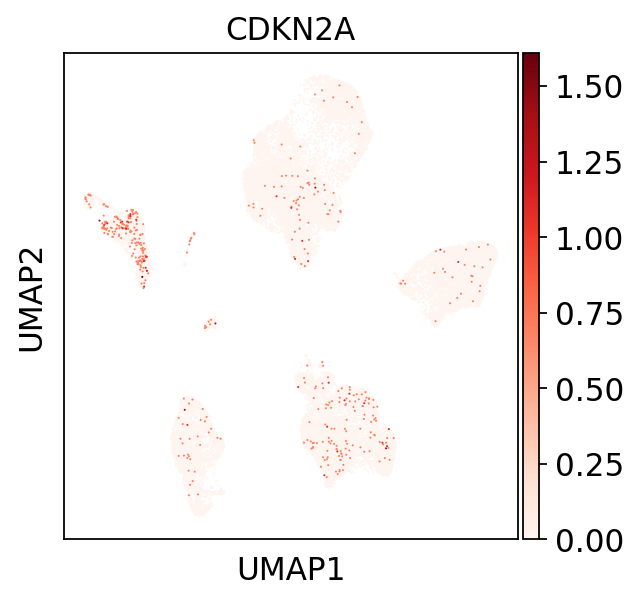

In [43]:
sc.pl.umap(card_cells, color='CDKN2A', color_map='Reds')

In [44]:
#note that some genes are stored only in raw, this includes CDKN2A/2B/ANRIL(2B-AS1)
card_cells.raw.var

,sct.detection_rate,sct.gmean,sct.variance,sct.residual_variance,sct.variable
AL627309.1,0.000985,0.000683,0.000985,0.935087,0
AL669831.5,0.006918,0.004889,0.007471,1.038071,0
FAM87B,0.001146,0.000795,0.001145,0.913662,0
LINC00115,0.017276,0.012170,0.017872,0.984170,0
FAM41C,0.000201,0.000139,0.000201,1.247764,0
...,...,...,...,...,...
AL354822.1,0.005511,0.003865,0.005821,1.091684,0
AC004556.1,0.004947,0.003484,0.005284,0.925907,0
AC233755.1,0.000141,0.000200,0.013394,2.609287,1
AC240274.1,0.026929,0.019363,0.030156,0.935729,0


In [45]:
card_cells.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito',
       'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'SCT_snn_res.0.3',
       'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6',
       'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9',
       'SCT_snn_res.1', 'seurat_clusters', 'Age_Group_Tertile', 'Sex',
       'Condition', 'Names', 'Cell_types', 'CDKN2A_p14', 'CDKN2A_p16',
       'CDKN2B_p15', 'CDKN2BAS1_ANRIL'],
      dtype='object')

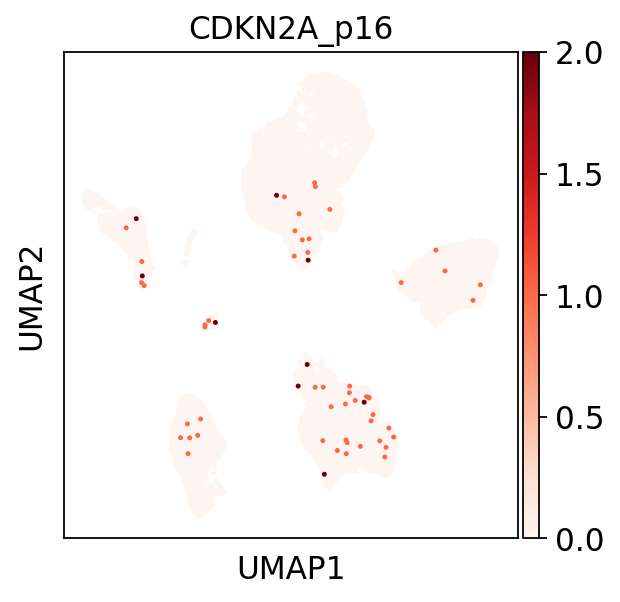

In [46]:
sc.pl.umap(card_cells, color='CDKN2A_p16', color_map='Reds', vmax='p99.995', size=20, save="Koenig_5prime_Cells_p16_RawCounts_forGH.pdf")

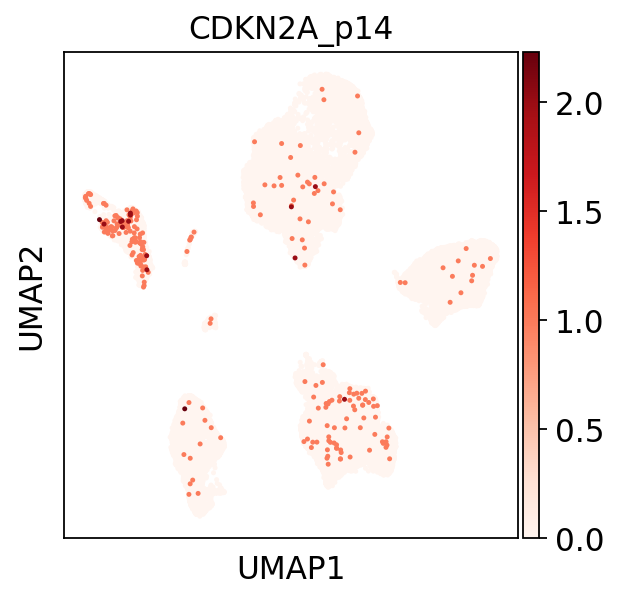

In [47]:
sc.pl.umap(card_cells, color='CDKN2A_p14', color_map='Reds', vmax='p99.995', size=20, save="Koenig_5prime_Cells_p14_RawCounts_forGH.pdf")

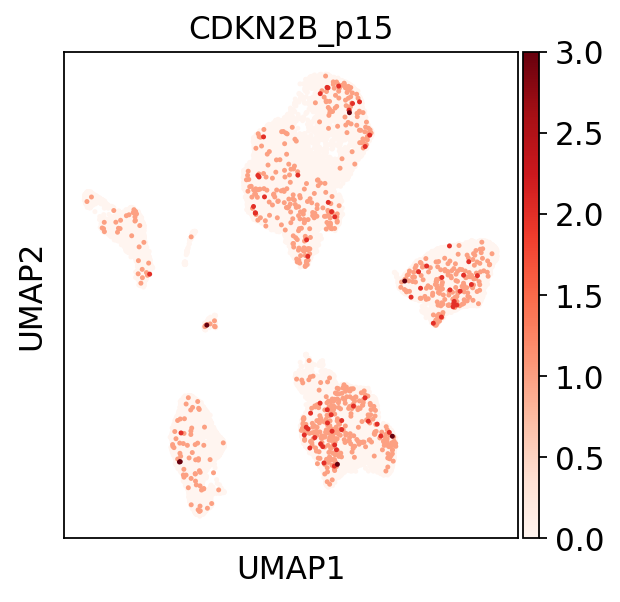

In [48]:
sc.pl.umap(card_cells, color='CDKN2B_p15', color_map='Reds', vmax='p99.995', size=20, save="Koenig_5prime_Cells_p15_RawCounts_forGH.pdf")

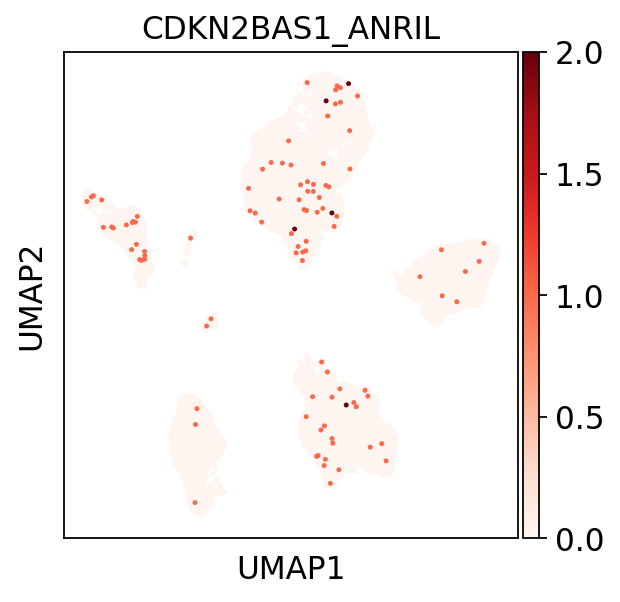

In [49]:
sc.pl.umap(card_cells, color='CDKN2BAS1_ANRIL', color_map='Reds', vmax='p99.995', size=20, save="Koenig_5prime_Cells_ANRIL_RawCounts_forGH.pdf")

In [50]:
card_cells.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent.mito,nCount_SCT,nFeature_SCT,SCT_snn_res.0.2,SCT_snn_res.0.3,SCT_snn_res.0.4,SCT_snn_res.0.5,...,seurat_clusters,Age_Group_Tertile,Sex,Condition,Names,Cell_types,CDKN2A_p14,CDKN2A_p16,CDKN2B_p15,CDKN2BAS1_ANRIL
HDCM1_AAACCTGCACTGTCGG,HDCM1,4998.0,2076,3.161265,4648.0,2076,0,0,0,0,...,16,Middle,Male,DCM,0,Fibroblasts,0.0,0.0,0.0,0.0
HDCM1_AAAGATGCACCGCTAG,HDCM1,6029.0,2474,3.566097,4928.0,2472,0,0,0,0,...,0,Middle,Male,DCM,0,Fibroblasts,0.0,0.0,0.0,0.0
HDCM1_AAAGATGCAGGAATGC,HDCM1,2486.0,1387,3.740949,3608.0,1422,0,0,0,5,...,0,Middle,Male,DCM,0,Fibroblasts,0.0,0.0,0.0,0.0
HDCM1_AAAGCAAGTCCGTGAC,HDCM1,4673.0,2383,1.776161,4554.0,2383,0,0,0,0,...,0,Middle,Male,DCM,0,Fibroblasts,0.0,0.0,0.0,0.0
HDCM1_AAAGTAGCATACGCCG,HDCM1,5034.0,2107,2.522845,4650.0,2107,0,0,0,0,...,0,Middle,Male,DCM,0,Fibroblasts,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HDCM8_TTCCCAGAGAGGTAGA,HDCM8,3258.0,1164,7.397176,3945.0,1163,8,12,14,18,...,24,Young,Female,DCM,9,B_Cells,0.0,0.0,0.0,0.0
HDCM8_TTTCCTCCAGATGGCA,HDCM8,5454.0,1747,4.767143,4724.0,1747,8,12,14,18,...,24,Young,Female,DCM,9,B_Cells,0.0,0.0,0.0,0.0
HDCM8_TTTGTCATCGCGATCG,HDCM8,5947.0,1866,5.683538,4831.0,1860,8,12,14,18,...,24,Young,Female,DCM,9,B_Cells,0.0,0.0,0.0,0.0
HDCM8_GACTAACTCAGGCAAG,HDCM8,3710.0,1742,3.638814,4019.0,1742,4,6,15,19,...,25,Young,Female,DCM,10,Lymphatic,0.0,0.0,0.0,0.0


In [51]:
card_tbl = sc.get.obs_df(card_cells,
                         keys=["orig.ident", "Cell_types", 
                               #all raw counts from remapping
                               'CDKN2A_p14', 'CDKN2A_p16', 'CDKN2B_p15', 'CDKN2BAS1_ANRIL'
                              ]
                        )

In [52]:
card_tbl

,orig.ident,Cell_types,CDKN2A_p14,CDKN2A_p16,CDKN2B_p15,CDKN2BAS1_ANRIL
HDCM1_AAACCTGCACTGTCGG,HDCM1,Fibroblasts,0.0,0.0,0.0,0.0
HDCM1_AAAGATGCACCGCTAG,HDCM1,Fibroblasts,0.0,0.0,0.0,0.0
HDCM1_AAAGATGCAGGAATGC,HDCM1,Fibroblasts,0.0,0.0,0.0,0.0
HDCM1_AAAGCAAGTCCGTGAC,HDCM1,Fibroblasts,0.0,0.0,0.0,0.0
HDCM1_AAAGTAGCATACGCCG,HDCM1,Fibroblasts,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
HDCM8_TTCCCAGAGAGGTAGA,HDCM8,B_Cells,0.0,0.0,0.0,0.0
HDCM8_TTTCCTCCAGATGGCA,HDCM8,B_Cells,0.0,0.0,0.0,0.0
HDCM8_TTTGTCATCGCGATCG,HDCM8,B_Cells,0.0,0.0,0.0,0.0
HDCM8_GACTAACTCAGGCAAG,HDCM8,Lymphatic,0.0,0.0,0.0,0.0


In [53]:
#new_order=['Fibroblasts','Endothelium','Pericytes','Smooth_Muscle','T_Cells','B_Cells','Macrophages','Monocytes','NK_Cells','Neurons','Lymphatic']
#card_tbl['Cell_types'] = card_tbl['Cell_types'].cat.reorder_categories(new_order, ordered=True)


In [54]:
#Create coarser cell type definitions to compare to other datasets
#Fibrobl > Mesenchymal
#Pericytes > Mesenchymal
#Smooth muscle > Mesenchymal

#Macrophages > Myeloid
#Monocytes > Myeloid
#NK cells are with T cells

In [55]:
card_tbl['Cell_types_coarse'] = card_tbl['Cell_types'].map({
    'Endothelium': 'Endothelial',

    'Fibroblasts': 'Mesenchymal',
    'Smooth_Muscle': 'Mesenchymal',
    'Pericytes': 'Mesenchymal',

    'T_Cells': 'Immune',
    'B_Cells': 'Immune',
    'Macrophages': 'Immune',
    'Monocytes': 'Immune',
    'NK_Cells': 'Immune',

    'Neurons': 'Neuronal',
    'Lymphatic': 'Lymphatic'
}).astype('category')

In [56]:
new_order=['Endothelial','Immune','Mesenchymal','Neuronal','Lymphatic']
card_tbl['Cell_types_coarse'] = card_tbl['Cell_types_coarse'].cat.reorder_categories(new_order, ordered=True)

In [57]:
card_tbl.Cell_types_coarse.value_counts(sort=False)

Endothelial     8890
Immune          5539
Mesenchymal    20678
Neuronal         242
Lymphatic         27
Name: Cell_types_coarse, dtype: int64

In [58]:
total_counts = card_tbl.groupby('Cell_types_coarse').size()
total_counts

Cell_types_coarse
Endothelial     8890
Immune          5539
Mesenchymal    20678
Neuronal         242
Lymphatic         27
dtype: int64

In [59]:
total_counts_bysamp = card_tbl.pivot_table(index='Cell_types_coarse', columns='orig.ident', aggfunc='size')
total_counts_bysamp

orig.ident,HDCM1,HDCM3,HDCM4,HDCM5,HDCM8
Cell_types_coarse,,,,,
Endothelial,2433,2149,1140,2218,950
Immune,969,1026,1449,368,1727
Mesenchymal,3967,4128,5617,4440,2526
Neuronal,52,114,14,4,58
Lymphatic,9,11,3,2,2


In [60]:
# Count rows where p14 > 0 per cell type
above_threshold_counts_p14 = card_tbl[card_tbl['CDKN2A_p14'] > 0].groupby('Cell_types_coarse').size()

# Calculate percentage 
percentage_above_threshold_p14 = (above_threshold_counts_p14 / total_counts) * 100

# Count expressing cells in each sample 
above_threshold_p14_bysamp = card_tbl[card_tbl['CDKN2A_p14'] > 0].pivot_table(index='Cell_types_coarse', columns='orig.ident', aggfunc='size', fill_value=0)

#  Calculate percentage  in each sample 
percentage_above_threshold_p14_bysamp=above_threshold_p14_bysamp/total_counts_bysamp*100
percentage_above_threshold_p14_bysamp

grouped_errors_p14_sem = percentage_above_threshold_p14_bysamp.sem(axis=1)


In [61]:
above_threshold_p14_bysamp

orig.ident,HDCM1,HDCM3,HDCM4,HDCM5,HDCM8
Cell_types_coarse,,,,,
Endothelial,8,4,9,35,14
Immune,21,10,37,3,85
Mesenchymal,6,4,21,8,13
Neuronal,0,0,1,0,1
Lymphatic,0,0,0,0,0


In [62]:
percentage_above_threshold_p14_bysamp

orig.ident,HDCM1,HDCM3,HDCM4,HDCM5,HDCM8
Cell_types_coarse,,,,,
Endothelial,0.328812,0.186133,0.789474,1.577998,1.473684
Immune,2.167183,0.974659,2.553485,0.815217,4.921830
Mesenchymal,0.151248,0.096899,0.373865,0.180180,0.514648
Neuronal,0.000000,0.000000,7.142857,0.000000,1.724138
Lymphatic,0.000000,0.000000,0.000000,0.000000,0.000000


In [63]:
# Count rows where p16 > 0 per cell type
above_threshold_counts_p16 = card_tbl[card_tbl['CDKN2A_p16'] > 0].groupby('Cell_types_coarse').size()

# Calculate percentage 
percentage_above_threshold_p16 = (above_threshold_counts_p16 / total_counts) * 100

# Count expressing cells in each sample 
above_threshold_p16_bysamp = card_tbl[card_tbl['CDKN2A_p16'] > 0].pivot_table(index='Cell_types_coarse', columns='orig.ident', aggfunc='size', fill_value=0)

#  Calculate percentage  in each sample 
percentage_above_threshold_p16_bysamp=above_threshold_p16_bysamp/total_counts_bysamp*100
percentage_above_threshold_p16_bysamp

grouped_errors_p16_sem = percentage_above_threshold_p16_bysamp.sem(axis=1)


In [64]:
above_threshold_p16_bysamp

orig.ident,HDCM1,HDCM3,HDCM4,HDCM5,HDCM8
Cell_types_coarse,,,,,
Endothelial,0,1,2,16,8
Immune,1,1,9,0,1
Mesenchymal,1,0,12,1,3
Neuronal,2,1,1,0,0
Lymphatic,0,0,0,0,0


In [65]:
# Count rows where p15 > 0 per cell type
above_threshold_counts_p15 = card_tbl[card_tbl['CDKN2B_p15'] > 0].groupby('Cell_types_coarse').size()

# Calculate percentage 
percentage_above_threshold_p15 = (above_threshold_counts_p15 / total_counts) * 100

# Count expressing cells in each sample 
above_threshold_p15_bysamp = card_tbl[card_tbl['CDKN2B_p15'] > 0].pivot_table(index='Cell_types_coarse', columns='orig.ident', aggfunc='size', fill_value=0)

#  Calculate percentage  in each sample 
percentage_above_threshold_p15_bysamp=above_threshold_p15_bysamp/total_counts_bysamp*100
percentage_above_threshold_p15_bysamp

grouped_errors_p15_sem = percentage_above_threshold_p15_bysamp.sem(axis=1)


In [66]:
above_threshold_p15_bysamp

orig.ident,HDCM1,HDCM3,HDCM4,HDCM5,HDCM8
Cell_types_coarse,,,,,
Endothelial,39,69,50,118,49
Immune,0,15,35,12,38
Mesenchymal,59,61,177,131,59
Neuronal,0,6,0,0,4
Lymphatic,0,0,0,0,0


In [67]:
percentage_above_threshold_p15_bysamp

orig.ident,HDCM1,HDCM3,HDCM4,HDCM5,HDCM8
Cell_types_coarse,,,,,
Endothelial,1.602959,3.210796,4.385965,5.320108,5.157895
Immune,0.000000,1.461988,2.415459,3.260870,2.200347
Mesenchymal,1.487270,1.477713,3.151148,2.950450,2.335709
Neuronal,0.000000,5.263158,0.000000,0.000000,6.896552
Lymphatic,0.000000,0.000000,0.000000,0.000000,0.000000


In [68]:
total_counts_bysamp

orig.ident,HDCM1,HDCM3,HDCM4,HDCM5,HDCM8
Cell_types_coarse,,,,,
Endothelial,2433,2149,1140,2218,950
Immune,969,1026,1449,368,1727
Mesenchymal,3967,4128,5617,4440,2526
Neuronal,52,114,14,4,58
Lymphatic,9,11,3,2,2


In [69]:
# Count rows where ANRIL > 0 per cell type
above_threshold_counts_ANRIL = card_tbl[card_tbl['CDKN2BAS1_ANRIL'] > 0].groupby('Cell_types_coarse').size()

# Calculate percentage 
percentage_above_threshold_ANRIL = (above_threshold_counts_ANRIL / total_counts) * 100

# Count expressing cells in each sample 
above_threshold_ANRIL_bysamp = card_tbl[card_tbl['CDKN2BAS1_ANRIL'] > 0].pivot_table(index='Cell_types_coarse', columns='orig.ident', aggfunc='size', fill_value=0)

#  Calculate percentage  in each sample 
percentage_above_threshold_ANRIL_bysamp=above_threshold_ANRIL_bysamp/total_counts_bysamp*100
percentage_above_threshold_ANRIL_bysamp

grouped_errors_ANRIL_sem = percentage_above_threshold_ANRIL_bysamp.sem(axis=1)


In [70]:
above_threshold_ANRIL_bysamp

orig.ident,HDCM1,HDCM3,HDCM4,HDCM5,HDCM8
Cell_types_coarse,,,,,
Endothelial,6,2,3,9,4
Immune,2,5,7,0,9
Mesenchymal,3,3,27,11,10
Neuronal,0,0,0,0,2
Lymphatic,0,0,0,0,0


In [71]:
percentage_above_threshold_ANRIL_bysamp

orig.ident,HDCM1,HDCM3,HDCM4,HDCM5,HDCM8
Cell_types_coarse,,,,,
Endothelial,0.246609,0.093067,0.263158,0.405771,0.421053
Immune,0.206398,0.487329,0.483092,0.000000,0.521135
Mesenchymal,0.075624,0.072674,0.480684,0.247748,0.395883
Neuronal,0.000000,0.000000,0.000000,0.000000,3.448276
Lymphatic,0.000000,0.000000,0.000000,0.000000,0.000000


In [72]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.style.use('default')

<Figure size 640x480 with 0 Axes>

In [73]:
percentage_above_threshold_p14_bysamp.mean(axis=1).values

array([0.87122027, 2.28647477, 0.26336798, 1.77339901, 0.        ])

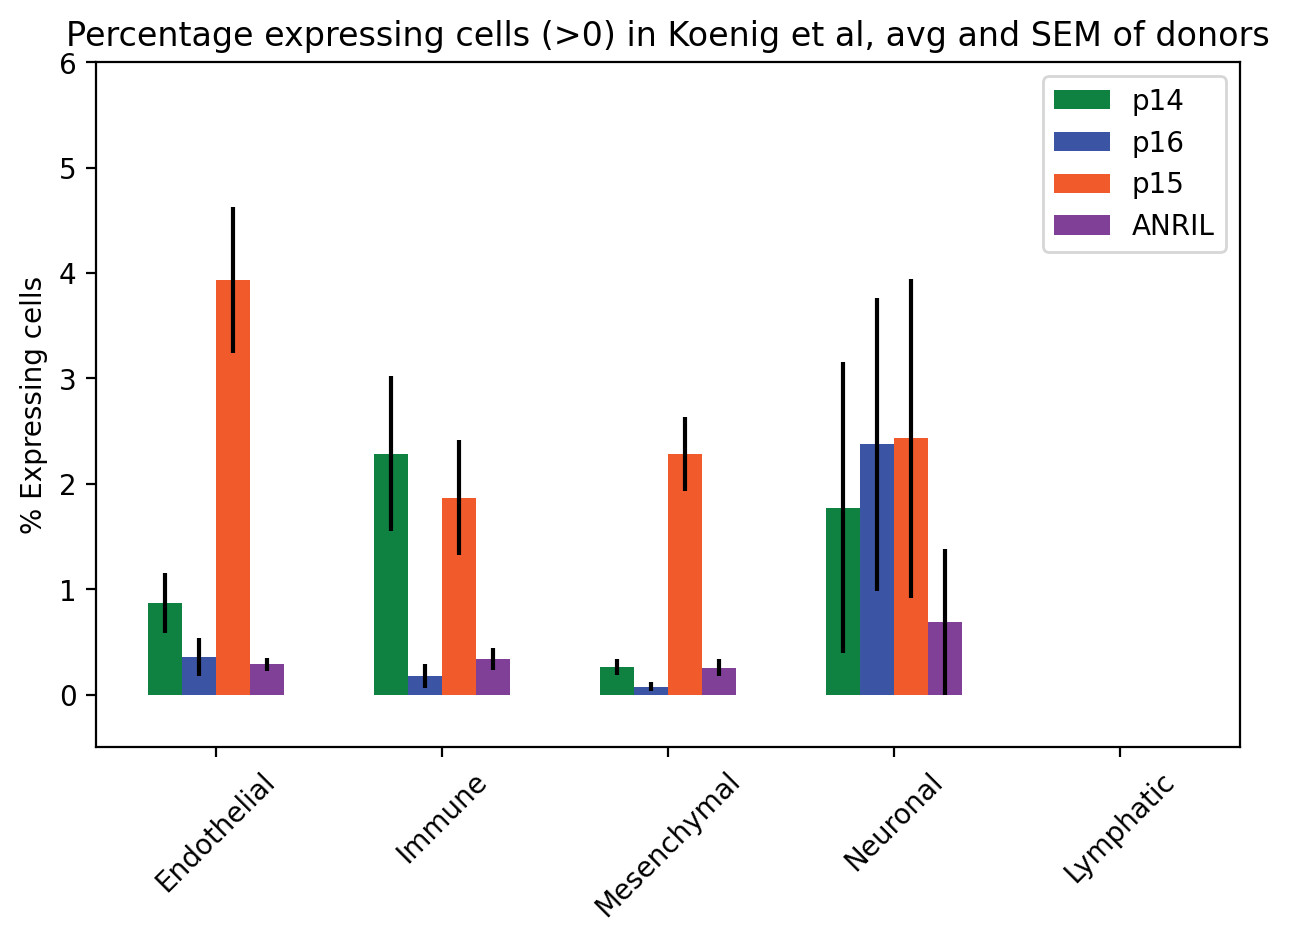

In [74]:
groups = ['Endothelial','Immune','Mesenchymal','Neuronal','Lymphatic']
# Bar width and positions
x = np.arange(len(groups))  # [0, 1, 2, 3, 4]
width = 0.15

colors = ['#0F8141','#3C54A4', '#F15A2B', '#804098']

fig, ax = plt.subplots()
ax.bar(x - 1.5*width, np.array(percentage_above_threshold_p14_bysamp.mean(axis=1).values), width, label='p14', yerr=grouped_errors_p14_sem,color=colors[0])
ax.bar(x - 0.5*width, np.array(percentage_above_threshold_p16_bysamp.mean(axis=1).values), width, label='p16', yerr=grouped_errors_p16_sem,color=colors[1])
ax.bar(x + 0.5*width, np.array(percentage_above_threshold_p15_bysamp.mean(axis=1).values), width, label='p15', yerr=grouped_errors_p15_sem,color=colors[2])
ax.bar(x + 1.5*width, np.array(percentage_above_threshold_ANRIL_bysamp.mean(axis=1).values), width, label='ANRIL', yerr=grouped_errors_ANRIL_sem,color=colors[3])

ax.set_xticks(x)
ax.set_xticklabels(groups)
plt.xticks(rotation=45)
ax.set_ylabel('% Expressing cells')
ax.set_title('Percentage expressing cells (>0) in Koenig et al, avg and SEM of donors')
ax.legend()

plt.ylim(-0.5,6)
plt.tight_layout()
plt.savefig("figures/Koenig_PercentExpressing_GroupedBarplot_GroupsAsGut_NewCols_avgSEMdonors.pdf", format='pdf', dpi=300)
plt.show()

In [75]:
only_imm=card_tbl[card_tbl['Cell_types_coarse']=='Immune']
only_imm

,orig.ident,Cell_types,CDKN2A_p14,CDKN2A_p16,CDKN2B_p15,CDKN2BAS1_ANRIL,Cell_types_coarse
HDCM1_AAACCTGGTGCTGTAT,HDCM1,Macrophages,0.0,0.0,0.0,0.0,Immune
HDCM1_AAACGGGGTGAAGGCT,HDCM1,Macrophages,0.0,0.0,0.0,0.0,Immune
HDCM1_AAATGCCCATTACCTT,HDCM1,Macrophages,0.0,0.0,0.0,0.0,Immune
HDCM1_AAATGCCTCTCTAGGA,HDCM1,Macrophages,0.0,0.0,0.0,0.0,Immune
HDCM1_AACCATGGTCACCTAA,HDCM1,Macrophages,0.0,0.0,0.0,0.0,Immune
...,...,...,...,...,...,...,...
HDCM8_TGGCCAGGTTAAGACA,HDCM8,B_Cells,0.0,0.0,0.0,0.0,Immune
HDCM8_TTAGGCAGTTTGTGTG,HDCM8,B_Cells,0.0,0.0,0.0,0.0,Immune
HDCM8_TTCCCAGAGAGGTAGA,HDCM8,B_Cells,0.0,0.0,0.0,0.0,Immune
HDCM8_TTTCCTCCAGATGGCA,HDCM8,B_Cells,0.0,0.0,0.0,0.0,Immune


In [76]:
only_imm['Cell_types']=only_imm['Cell_types'].cat.remove_unused_categories()

/local/scratch/53448706.1.broad/ipykernel_81131/814850262.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  only_imm['Cell_types']=only_imm['Cell_types'].cat.remove_unused_categories()


In [77]:
only_imm.Cell_types.value_counts()

Macrophages    2710
T_Cells        1797
Monocytes       522
NK_Cells        354
B_Cells         156
Name: Cell_types, dtype: int64

In [78]:
only_imm['Cell_types2'] = only_imm['Cell_types'].map({
    'T_Cells': 'T cells',
    'B_Cells': 'B cells',
    'Macrophages': 'Myeloid',
    'Monocytes': 'Myeloid',
    'NK_Cells': 'NK cells',
}).astype('category')

/local/scratch/53448706.1.broad/ipykernel_81131/3250941905.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  only_imm['Cell_types2'] = only_imm['Cell_types'].map({


In [79]:
new_order=['T cells', 'NK cells','B cells','Myeloid']
only_imm['Cell_types2'] = only_imm['Cell_types2'].cat.reorder_categories(new_order, ordered=True)

/local/scratch/53448706.1.broad/ipykernel_81131/2285575469.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  only_imm['Cell_types2'] = only_imm['Cell_types2'].cat.reorder_categories(new_order, ordered=True)


In [80]:
only_imm.Cell_types2.value_counts(sort=False)

T cells     1797
NK cells     354
B cells      156
Myeloid     3232
Name: Cell_types2, dtype: int64

In [81]:
only_imm_total_counts = only_imm.groupby('Cell_types2').size()
only_imm_total_counts

Cell_types2
T cells     1797
NK cells     354
B cells      156
Myeloid     3232
dtype: int64

In [82]:
only_imm_total_counts_bysamp = only_imm.pivot_table(index='Cell_types2', columns='orig.ident', aggfunc='size')
only_imm_total_counts_bysamp

orig.ident,HDCM1,HDCM3,HDCM4,HDCM5,HDCM8
Cell_types2,,,,,
T cells,579,196,234,85,703
NK cells,85,95,88,38,48
B cells,6,24,53,4,69
Myeloid,299,711,1074,241,907


In [83]:
# Count rows where p14 > 0 per cell type
only_imm_above_threshold_counts_p14 = only_imm[only_imm['CDKN2A_p14'] > 0].groupby('Cell_types2').size()

# Calculate percentage 
only_imm_percentage_above_threshold_p14 = (only_imm_above_threshold_counts_p14 / only_imm_total_counts) * 100

# Count expressing cells in each sample 
only_imm_above_threshold_p14_bysamp = only_imm[only_imm['CDKN2A_p14'] > 0].pivot_table(index='Cell_types2', columns='orig.ident', aggfunc='size', fill_value=0)

#  Calculate percentage  in each sample 
only_imm_percentage_above_threshold_p14_bysamp=only_imm_above_threshold_p14_bysamp/only_imm_total_counts_bysamp*100
only_imm_percentage_above_threshold_p14_bysamp

only_imm_grouped_errors_p14_sem = only_imm_percentage_above_threshold_p14_bysamp.sem(axis=1)


In [84]:
only_imm_above_threshold_p14_bysamp

orig.ident,HDCM1,HDCM3,HDCM4,HDCM5,HDCM8
Cell_types2,,,,,
T cells,17,6,24,2,75
NK cells,3,3,5,0,2
B cells,0,0,4,0,2
Myeloid,1,1,4,1,6


In [85]:
only_imm_percentage_above_threshold_p14_bysamp

orig.ident,HDCM1,HDCM3,HDCM4,HDCM5,HDCM8
Cell_types2,,,,,
T cells,2.936097,3.061224,10.256410,2.352941,10.668563
NK cells,3.529412,3.157895,5.681818,0.000000,4.166667
B cells,0.000000,0.000000,7.547170,0.000000,2.898551
Myeloid,0.334448,0.140647,0.372439,0.414938,0.661521


In [86]:
# Count rows where p16 > 0 per cell type
only_imm_above_threshold_counts_p16 = only_imm[only_imm['CDKN2A_p16'] > 0].groupby('Cell_types2').size()

# Calculate percentage 
only_imm_percentage_above_threshold_p16 = (only_imm_above_threshold_counts_p16 / only_imm_total_counts) * 100

# Count expressing cells in each sample 
only_imm_above_threshold_p16_bysamp = only_imm[only_imm['CDKN2A_p16'] > 0].pivot_table(index='Cell_types2', columns='orig.ident', aggfunc='size', fill_value=0)

#  Calculate percentage  in each sample 
only_imm_percentage_above_threshold_p16_bysamp=only_imm_above_threshold_p16_bysamp/only_imm_total_counts_bysamp*100
only_imm_percentage_above_threshold_p16_bysamp

only_imm_grouped_errors_p16_sem = only_imm_percentage_above_threshold_p16_bysamp.sem(axis=1)


In [87]:
# Count rows where p15 > 0 per cell type
only_imm_above_threshold_counts_p15 = only_imm[only_imm['CDKN2B_p15'] > 0].groupby('Cell_types2').size()

# Calculate percentage 
only_imm_percentage_above_threshold_p15 = (only_imm_above_threshold_counts_p15 / only_imm_total_counts) * 100

# Count expressing cells in each sample 
only_imm_above_threshold_p15_bysamp = only_imm[only_imm['CDKN2B_p15'] > 0].pivot_table(index='Cell_types2', columns='orig.ident', aggfunc='size', fill_value=0)

#  Calculate percentage  in each sample 
only_imm_percentage_above_threshold_p15_bysamp=only_imm_above_threshold_p15_bysamp/only_imm_total_counts_bysamp*100
only_imm_percentage_above_threshold_p15_bysamp

##remove the outlier 25% coming from 1 cell of 4 in HDCM5
#this is the only non-0 value coming from a group of < 5 cells 

only_imm_percentage_above_threshold_p15_bysamp.loc['B cells', 'HDCM5']=0

only_imm_grouped_errors_p15_sem = only_imm_percentage_above_threshold_p15_bysamp.sem(axis=1)



In [88]:
only_imm_percentage_above_threshold_p15_bysamp

orig.ident,HDCM1,HDCM3,HDCM4,HDCM5,HDCM8
Cell_types2,,,,,
T cells,0.0,2.040816,3.418803,4.705882,2.418208
NK cells,0.0,1.052632,1.136364,0.000000,0.000000
B cells,0.0,0.000000,0.000000,0.000000,0.000000
Myeloid,0.0,1.406470,2.420857,2.904564,2.315325


In [89]:
only_imm_grouped_errors_p15_sem

Cell_types2
T cells     0.780265
NK cells    0.268423
B cells     0.000000
Myeloid     0.513104
dtype: float64

In [90]:
# Count rows where ANRIL > 0 per cell type
only_imm_above_threshold_counts_ANRIL = only_imm[only_imm['CDKN2BAS1_ANRIL'] > 0].groupby('Cell_types2').size()

# Calculate percentage 
only_imm_percentage_above_threshold_ANRIL = (only_imm_above_threshold_counts_ANRIL / only_imm_total_counts) * 100

# Count expressing cells in each sample 
only_imm_above_threshold_ANRIL_bysamp = only_imm[only_imm['CDKN2BAS1_ANRIL'] > 0].pivot_table(index='Cell_types2', columns='orig.ident', aggfunc='size', fill_value=0)

#  Calculate percentage  in each sample 
only_imm_percentage_above_threshold_ANRIL_bysamp=only_imm_above_threshold_ANRIL_bysamp/only_imm_total_counts_bysamp*100
only_imm_percentage_above_threshold_ANRIL_bysamp

only_imm_grouped_errors_ANRIL_sem = only_imm_percentage_above_threshold_ANRIL_bysamp.sem(axis=1)



In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [ ]:
plt.rcParams['figure.figsize'] = (8, 6)


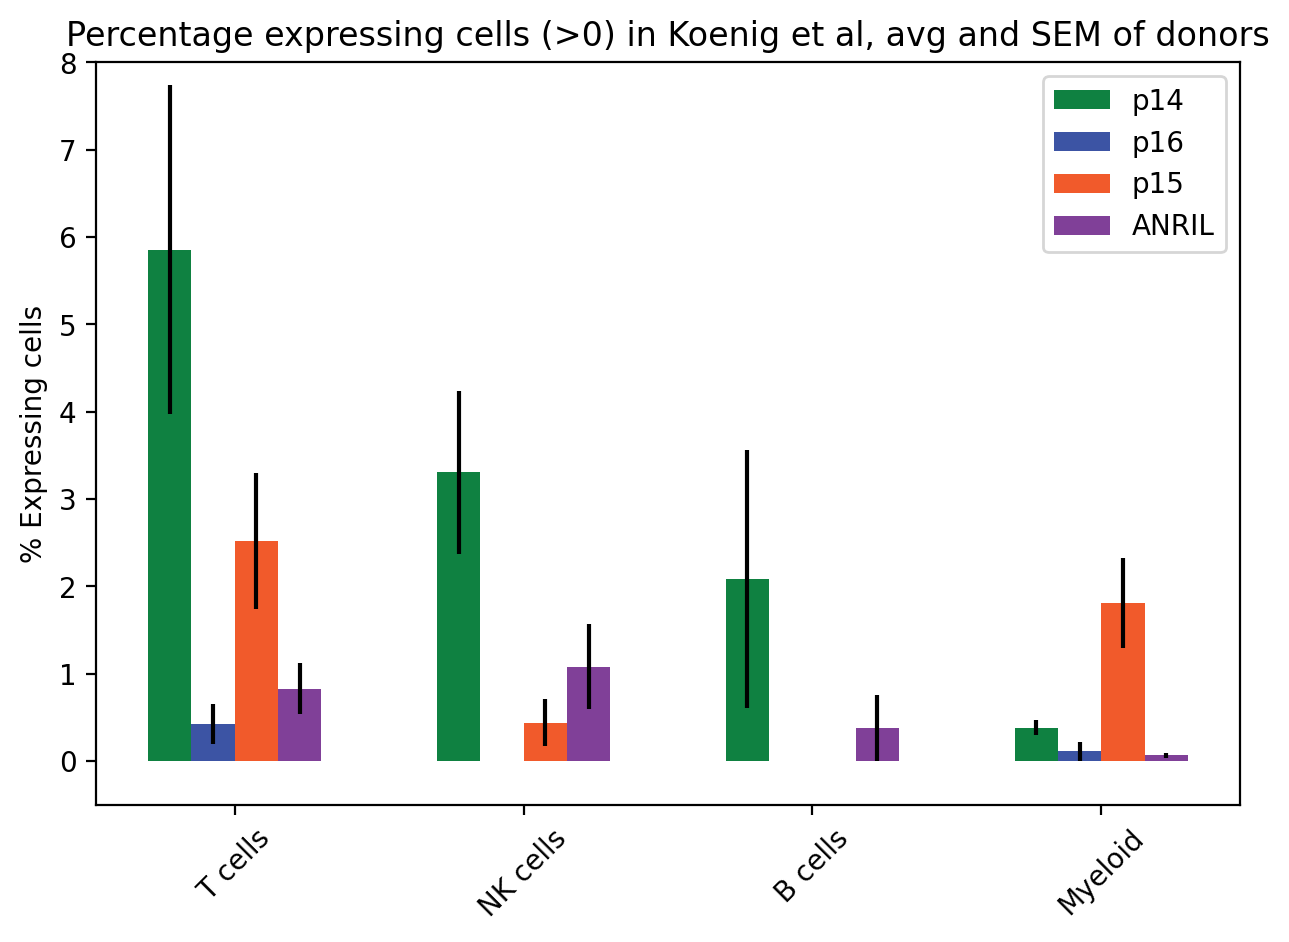

In [93]:
groups = ['T cells', 'NK cells','B cells','Myeloid']
# Bar width and positions
x = np.arange(len(groups))  # [0, 1, 2, 3, 4]
width = 0.15

colors = ['#0F8141','#3C54A4', '#F15A2B', '#804098']

fig, ax = plt.subplots()
ax.bar(x - 1.5*width, np.array(only_imm_percentage_above_threshold_p14_bysamp.mean(axis=1).values), width, label='p14', yerr=only_imm_grouped_errors_p14_sem,color=colors[0])
ax.bar(x - 0.5*width, np.array(only_imm_percentage_above_threshold_p16_bysamp.mean(axis=1).values), width, label='p16', yerr=only_imm_grouped_errors_p16_sem,color=colors[1])
ax.bar(x + 0.5*width, np.array(only_imm_percentage_above_threshold_p15_bysamp.mean(axis=1).values), width, label='p15', yerr=only_imm_grouped_errors_p15_sem,color=colors[2])
ax.bar(x + 1.5*width, np.array(only_imm_percentage_above_threshold_ANRIL_bysamp.mean(axis=1).values), width, label='ANRIL', yerr=only_imm_grouped_errors_ANRIL_sem,color=colors[3])

ax.set_xticks(x)
ax.set_xticklabels(groups)
plt.xticks(rotation=45)
ax.set_ylabel('% Expressing cells')

ax.set_title('Percentage expressing cells (>0) in Koenig et al, avg and SEM of donors')
ax.legend()

plt.ylim(-0.5,8)
plt.tight_layout()
plt.savefig("figures/Koenig_PercentExpressing_GroupedBarplot_T_NKCellsSep_NewCols_onlyImmune_avgSEMdonors.pdf", format='pdf', dpi=300)
plt.show()